# Prediction of Cheating in films ~ANALYSIS

**Author**: Nina Vivier Barte et Yacine Touileb

**Date**: 23th November 2024

# 1. Introduction

As part of a study on romantic love in films, it is relevant to develop a method for predicting, based on a film's description, whether the plot will involve a cheating or jealousy situation. This is a classification problem.

**Objective**: Predict whether a film's plot involves a cheating situation or jealousy.

# 2. Library Import and Function Construction

In [1]:
# Importing necessary libraries

# Data manipulation and analysis
import pandas as pd  

# Visualization tools
import matplotlib.pyplot as plt  
import seaborn as sns  

# Numerical computations
import numpy as np  

# Scikit-learn modules for machine learning

# Splitting datasets into training and testing sets
from sklearn.model_selection import train_test_split  

# Preprocessing: Standardizing features by removing the mean and scaling to unit variance
from sklearn.preprocessing import StandardScaler  

# Evaluation metrics for model performance
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, classification_report  

# Machine learning models
from sklearn.linear_model import LogisticRegression  # Logistic Regression model
from sklearn.ensemble import RandomForestClassifier  # Random Forest model
from sklearn.neural_network import MLPClassifier  # Multi-Layer Perceptron (Neural Network) model


In [2]:
def plot_sorted_coefficients(coef, threshold = 1e-08, analysis = 'embedding', ax = None):

    # Sort the coefficients by their absolute values
    sorted_coef = coef.abs().sort_values(ascending = False)

    # Keep only the 30 most important features
    top_n = 30
    sorted_coef = sorted_coef[:top_n]

    # Get the original coefficients for coloring
    original_sorted_coef = coef.loc[sorted_coef.index]
    
    # Create a scatter plot with bars
    if ax is None:
        fig, ax = plt.subplots(figsize = (8, 10))
    
    # Plot positive coefficients in green, negative coefficients in red, and near-zero coefficients in grey
    colors = [
        'grey' if abs(c) < threshold else 'green' if c > 0 else 'red'
        for c in original_sorted_coef
    ]
    
    # Scatter plot for coefficients
    ax.scatter(sorted_coef.values, sorted_coef.index, color = colors, zorder = 5)
    
    # Plot lines from the origin to the scatter points
    for i in range(len(sorted_coef)):
        ax.plot([0, sorted_coef.values[i]], [i, i], color = 'skyblue', lw = 2)

    # To have the most important feature at the top
    ax.invert_yaxis()
    
    # Add vertical line at zero
    ax.axvline(x = 0, color = 'gray', linestyle = '--', linewidth = 1)
    
    # Set labels and title
    ax.set_xlabel('Absolute Coefficient Value')
    ax.set_ylabel('Features')

    

# 3. Data Import

In [3]:
df = pd.read_csv('Letterboxd_annotations - Letterboxd_annotations.csv')
df 

,NOM,PRENOM,id,name,description,link,pstrN,pstrNF,pstrNH,pstrVisages,pstrContact,txtMarr,txtCheat,txtDivorce,txtRelAvant,txtRelPendant,love
0,ALAOUI BOUHAMID,Sara,1294927,Stone Age Stunts,A cave man gets up in the morning to walk arou...,https://a.ltrbxd.com/resized/film-poster/3/5/6...,2,2,0,0,0,0,0,0,0,0,1
1,ALAOUI BOUHAMID,Sara,1393413,Anarkali,"Prince Salim, son of Akbar falls in love with ...",https://a.ltrbxd.com/resized/film-poster/3/7/3...,1,1,0,0,0,1,0,0,1,0,2
2,ALAOUI BOUHAMID,Sara,1274166,Człowiek z M-3,A young doctor receives an allotment for a sta...,https://a.ltrbxd.com/resized/film-poster/1/4/9...,0,0,0,0,0,1,0,0,0,0,1
3,ALAOUI BOUHAMID,Sara,1013754,The Shape of Things,"Quiet, unassuming Adam is changing in a major ...",https://a.ltrbxd.com/resized/film-poster/3/7/6...,2,1,1,0,1,0,0,0,1,0,1
4,ALAOUI BOUHAMID,Sara,1041125,Love and Bullets,A Camorra boss fakes his own death in order to...,https://a.ltrbxd.com/resized/film-poster/3/9/9...,2,1,1,0,1,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2314,VIVIER--BARTE,Nina,1413542,Exposição,"During the pandemic, introverted painter Hélio...",https://a.ltrbxd.com/resized/film-poster/1/1/7...,1,0,1,0,0,0,0,0,0,0,0
2315,VIVIER--BARTE,Nina,1110049,Perfect One-Night Stand,I really want to have sex before I turn 21! Ji...,https://a.ltrbxd.com/resized/film-poster/5/8/9...,2,2,0,0,0,0,0,0,0,1,2
2316,VIVIER--BARTE,Nina,1082796,"Sakal, Sakali, Saklolo","Newlywed Jed and Angie this time, they have to...",https://a.ltrbxd.com/resized/film-poster/1/1/7...,16,7,9,0,1,0,1,0,1,1,1
2317,VIVIER--BARTE,Nina,1028392,Abbas in Flower,While working as an assistant to swindling dri...,https://a.ltrbxd.com/resized/film-poster/1/1/7...,2,0,2,1,0,0,0,0,0,1,2


# 4. Data Description

C:\Users\33768\AppData\Local\Temp\ipykernel_14424\2564380323.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Cheating', 'Cheating'])


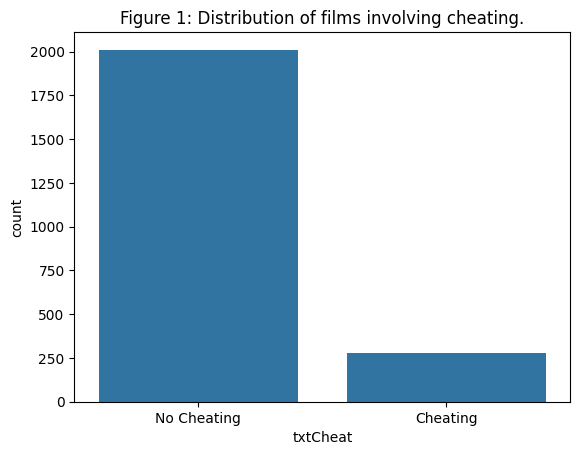

In [4]:
# Filter the dataset to include only rows where 'txtCheat' is either '0' (No Cheating) or '1' (Cheating)
df = df[df['txtCheat'].isin(['0', '1'])]
df.reset_index(drop=True, inplace=True)  # Reset the index after filtering

# Create a bar plot to visualize the distribution of cheating versus non-cheating films
ax = sns.countplot(x=df['txtCheat'])
ax.set_xticklabels(['No Cheating', 'Cheating'])
ax.set_title('Figure 1: Distribution of films involving cheating.') 

plt.show()

# 5. Data Manipulation

## 5.1 Specific bag of words

In [5]:
# Load the dataset and clean it by dropping unnecessary columns and handling invalid or missing values
df1 = pd.read_csv('baby_bagofwords.csv')  # Load the dataset
df1 = df1.drop(columns=['sentence'])  # Remove the 'sentence' column as it's not needed
df1 = df1[df1['txtCheat'] != '?']  # Exclude rows with invalid 'txtCheat' values

# Standardize the 'txtCheat' column and remove rows with missing values
df1['txtCheat'] = df1['txtCheat'].replace({'0': 0, '1': 1})  # Convert 'txtCheat' values to integers
df1 = df1.dropna(subset=['txtCheat'])  # Drop rows where 'txtCheat' has missing values


C:\Users\33768\AppData\Local\Temp\ipykernel_14424\3097110853.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1['txtCheat'] = df1['txtCheat'].replace({'0': 0, '1': 1})  # Convert 'txtCheat' values to integers


## 5.2  General bag of words

In [6]:
# Load the dataset and clean it by dropping unnecessary columns and handling invalid or missing values
df2 = pd.read_csv('bagofwords.csv')
df2 = df2.drop(columns=['description'])
df2 = df2[df2['txtCheat'] != '?']

# Standardize the 'txtCheat' column and remove rows with missing values
df2['txtCheat'] = df2['txtCheat'].replace({'0': 0 , '1': 1})
df2 = df2.dropna(subset=['txtCheat'])  

C:\Users\33768\AppData\Local\Temp\ipykernel_14424\1832603265.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2['txtCheat'] = df2['txtCheat'].replace({'0': 0 , '1': 1})


## 5.3 Word embeddings

In [7]:
# Load the dataset and clean it by dropping unnecessary columns and handling invalid or missing values
df3 = pd.read_csv('word_embeddings.csv')
df3 = df3.drop(columns=['description'])
df3 = df3[df3['txtCheat'] != '?']

# Standardize the 'txtCheat' column and remove rows with missing values
df3['txtCheat'] = df3['txtCheat'].replace({'0': 0 , '1': 1})
df3['txtCheat'] = df3['txtCheat'].replace({0.0: 0 , 1.0: 1})
df3 = df3.dropna(subset=['txtCheat'])  


C:\Users\33768\AppData\Local\Temp\ipykernel_14424\2206118754.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df3 = pd.read_csv('word_embeddings.csv')
C:\Users\33768\AppData\Local\Temp\ipykernel_14424\2206118754.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df3['txtCheat'] = df3['txtCheat'].replace({'0': 0 , '1': 1})


# 6. Data Normalization

## 6.1 Dataframe with the specific bag of words

In [8]:
# Separate the target variable from the rest of the dataset
y = df1['txtCheat']
features = df1.drop(columns=['txtCheat'])

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(features)
X = pd.DataFrame(X, columns = features.columns)

# Merge the data
df1 = X.copy()
df1['txtCheat'] = y

df1.dropna(inplace=True)

## 6.2 Dataframe with the general bag of words

In [9]:
# Separate the target variable from the rest of the dataset
y = df2['txtCheat']
features = df2.drop(columns=['txtCheat'])

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(features)
X = pd.DataFrame(X, columns = features.columns)

# Merge the data
df2 = X.copy()
df2['txtCheat'] = y

df2.dropna(inplace=True)

## 6.3 Dataframe with the word embeddings

In [10]:
# Separate the target variable from the rest of the dataset
y = df3['txtCheat']
features = df3.drop(columns=['txtCheat'])

# Standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(features)
X = pd.DataFrame(X, columns = features.columns)

# Merge the data
df3 = X.copy()
df3['txtCheat'] = y

df3.dropna(inplace=True)

# 7. Train and Test Split

## 7.1 Specific bag of words

In [11]:
# Splitting the dataset into train and test
X1 = df1.drop("txtCheat", axis = 1)
y1 = df1["txtCheat"]

X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size = 0.2, random_state = 667)

## 7.2 General bag of words

In [12]:
# Splitting the dataset into train and test
X2 = df2.drop("txtCheat", axis = 1)
y2 = df2["txtCheat"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size = 0.2, random_state = 667)

## 7.3 Word embeddings 

In [13]:
# Splitting the dataset into train and test
X3 = df3.drop("txtCheat", axis = 1)
y3 = df3["txtCheat"]

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3, test_size = 0.2, random_state = 667)

# 8. Data Modelling

## 8.1 Logistic Regression Model

### 8.1.1 Logistic regression using the specific bag of words

In [14]:
# Performing Logistic Regression for the Specific Bag of Words
reg1 = LogisticRegression(max_iter = 10000)
reg1.fit(X_train1, y_train1)

coef1 = pd.Series(reg1.coef_.flatten(), index = X_train1.columns)

In [15]:
# Test the logistic regression
y_pred1 = reg1.predict(X_test1)

# Confusion matrix
cm1 = confusion_matrix(y_test1, y_pred1)
cm_df1 = pd.DataFrame(cm1, index=['Not Cheat', 'Cheat'], columns=['Predicted Not Cheat', 'Predicted Cheat'])
print("Confusion Matrix:")
print(cm_df1)

Confusion Matrix:
           Predicted Not Cheat  Predicted Cheat
Not Cheat                  397                0
Cheat                       54                0


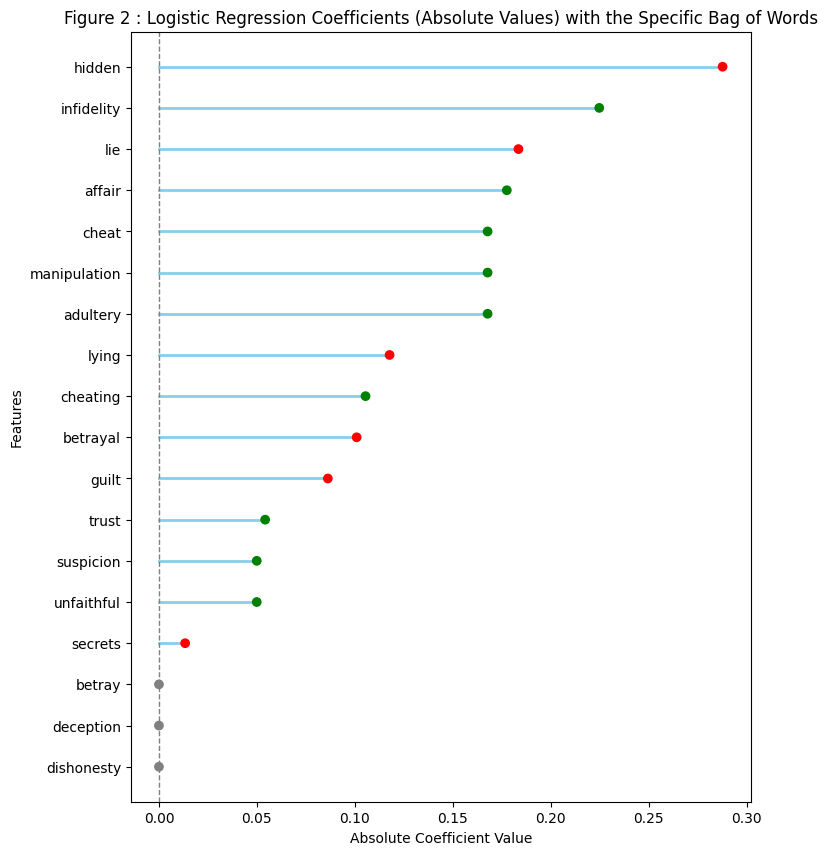

In [16]:
plot_sorted_coefficients(coef1)
plt.title("Figure 2 : Logistic Regression Coefficients (Absolute Values) with the Specific Bag of Words")
plt.show()


In [17]:
# Recall calculation on test data
recall_test = recall_score(y_test1, y_pred1)
print("recall test =", recall_test)

# Prediction on training data
y_train_pred1 = reg1.predict(X_train1)

# Recall calculation based on training data
recall_train = recall_score(y_train1, y_train_pred1)
print("recall train =", recall_train) 

# Difference between training and test recall
print("recall train - recall test =",recall_train - recall_test)

recall test = 0.0
recall train = 0.02336448598130841
recall train - recall test = 0.02336448598130841


We focus on recall rather than accuracy because our dataset contains significantly more 'no cheating' instances than 'cheating' ones. This imbalance makes recall a better metric for diagnosing model performance.

Given the presence of both bias and variance, we first address the bias by using a dataset with more features, specifically the one corresponding to the 'general bag of words' approach.
 

### 8.1.2 Logistic regression using the general bag of words

In [18]:
# Performing Logistic Regression for the General Bag of Words
reg2 = LogisticRegression()
reg2.fit(X_train2, y_train2)

coef2 = pd.Series(reg2.coef_[0], index = X2.columns)

In [19]:
# Test the logistic regression
y_pred2 = reg2.predict(X_test2)

# Confusion matrix
cm2 = confusion_matrix(y_test2, y_pred2)
cm_df2 = pd.DataFrame(cm2, index=['Not Cheat', 'Cheat'], columns=['Predicted Not Cheat', 'Predicted Cheat'])
print("Confusion Matrix:")
print(cm_df2)

Confusion Matrix:
           Predicted Not Cheat  Predicted Cheat
Not Cheat                  392                5
Cheat                       53                1


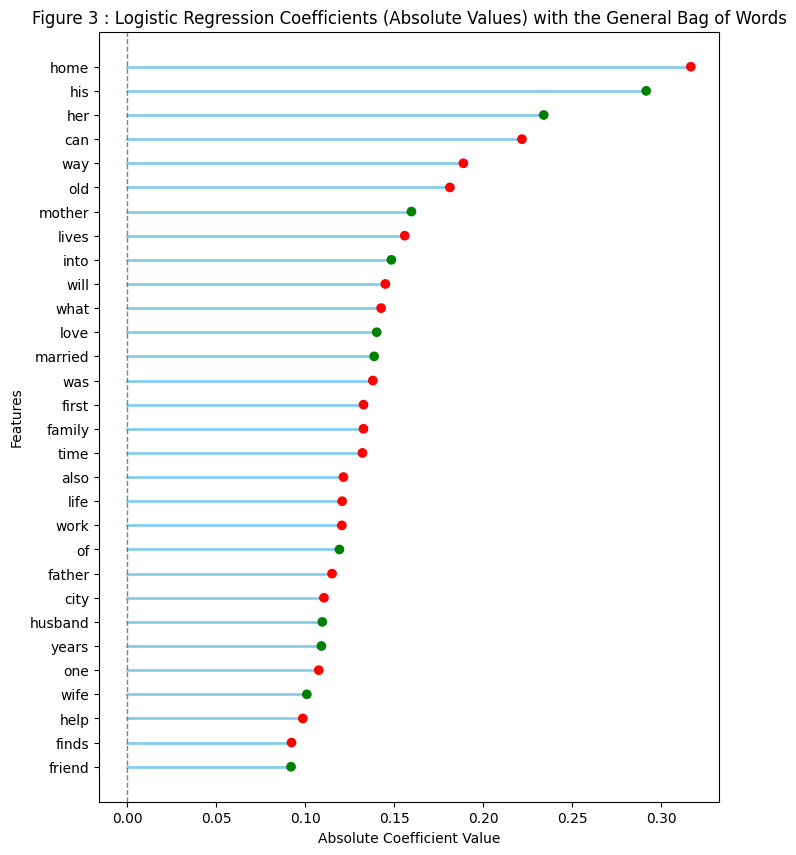

In [20]:
plot_sorted_coefficients(coef2)
plt.title("Figure 3 : Logistic Regression Coefficients (Absolute Values) with the General Bag of Words")
plt.show()

In [21]:
# Recall calculation on test data
recall_test = recall_score(y_test2, y_pred2)
print("recall test =", recall_test)

# Prediction on training data
y_train_pred2 = reg2.predict(X_train2)

# Recall calculation based on training data
recall_train = recall_score(y_train2, y_train_pred2)
print("recall train =", recall_train) 

# Difference between training and test recall
print("recall train - recall test =",recall_train - recall_test)

recall test = 0.018518518518518517
recall train = 0.028037383177570093
recall train - recall test = 0.009518864659051576


There is also a significant bias, which is why we need to switch to a dataset with more features—specifically, the word embeddings.

### 8.1.3 Logistic regression using word embeddings

In [22]:
# Performing Logistic Regression for Word Embeddings
reg3 = LogisticRegression(max_iter = 10000)
reg3.fit(X_train3, y_train3)

coef3 = pd.Series(reg3.coef_.flatten(), index = X_train3.columns)

In [23]:
# Test the logistic regression
y_pred3 = reg3.predict(X_test3)

# Confusion matrix
cm3 = confusion_matrix(y_test3, y_pred3)
cm_df3 = pd.DataFrame(cm3, index=['Not Cheat', 'Cheat'], columns=['Predicted Not Cheat', 'Predicted Cheat'])
print("Confusion Matrix:")
print(cm_df3)

Confusion Matrix:
           Predicted Not Cheat  Predicted Cheat
Not Cheat                  377               20
Cheat                       51                3


In [24]:
# Recall calculation on test data
recall_test = recall_score(y_test3, y_pred3)
print("recall test =", recall_test)

# Prediction on training data
y_train_pred3 = reg3.predict(X_train3)

# Recall calculation based on training data
recall_train = recall_score(y_train3, y_train_pred3)
print("recall train =", recall_train) 

# Difference between training and test recall
print("recall train - recall test =",recall_train - recall_test)

recall test = 0.05555555555555555
recall train = 0.17757009345794392
recall train - recall test = 0.12201453790238836


We are facing too much bias, and adding more features is not an option. Therefore, we need a more sophisticated model, which in this case is the neural network.

## 8.2 Neural Network Model

### 8.2.1 Neural Network using the Specific Bag of Words

In [25]:
# Neural Network using the Specific Bag of Words NUMBER 1
clf_neurons1 = MLPClassifier(hidden_layer_sizes=(200,200), activation = 'relu',
                              solver='adam', max_iter = 500, alpha=15, tol = 1e-8, batch_size= 1000,
                              random_state = 666, verbose = True
                              )

# Train the network
clf_neurons1.fit(X_train1, y_train1)

# Predict on the test set
y_pred1 = clf_neurons1.predict(X_test1)

Iteration 1, loss = 2.51521240
Iteration 2, loss = 2.38839157
Iteration 3, loss = 2.28006389
Iteration 4, loss = 2.18066513
Iteration 5, loss = 2.08948253
Iteration 6, loss = 2.00434067
Iteration 7, loss = 1.92386667
Iteration 8, loss = 1.84885478
Iteration 9, loss = 1.77821888
Iteration 10, loss = 1.71143344
Iteration 11, loss = 1.64746474
Iteration 12, loss = 1.58649805
Iteration 13, loss = 1.52836110
Iteration 14, loss = 1.47269534
Iteration 15, loss = 1.41890163
Iteration 16, loss = 1.36762306
Iteration 17, loss = 1.31839652
Iteration 18, loss = 1.27120049
Iteration 19, loss = 1.22609532
Iteration 20, loss = 1.18283736
Iteration 21, loss = 1.14152755
Iteration 22, loss = 1.10216244
Iteration 23, loss = 1.06470873
Iteration 24, loss = 1.02896726
Iteration 25, loss = 0.99500524
Iteration 26, loss = 0.96265792
Iteration 27, loss = 0.93186288
Iteration 28, loss = 0.90257913
Iteration 29, loss = 0.87478444
Iteration 30, loss = 0.84819904
Iteration 31, loss = 0.82296965
Iteration 32, los

c:\Users\33768\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


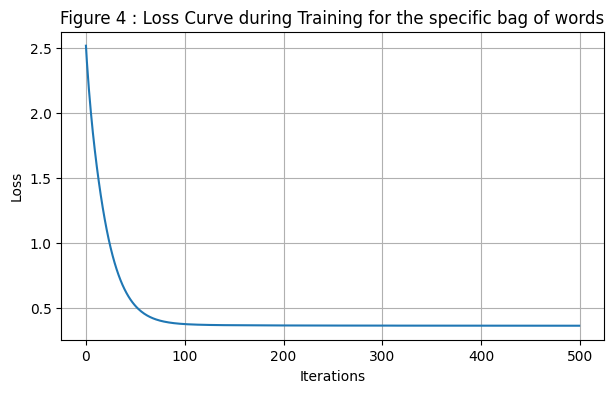

In [26]:
# Plot the loss curve
plt.figure(figsize = (7, 4))
plt.plot(clf_neurons1.loss_curve_)
plt.title('Figure 4 : Loss Curve during Training for the specific bag of words')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [27]:
# Confusion matrix
cm1 = confusion_matrix(y_test1, y_pred1)
cm_df1 = pd.DataFrame(cm1, index=['Not Cheat', 'Cheat'], columns=['Predicted Not Cheat', 'Predicted Cheat'])
print("Confusion Matrix:")
print(cm_df1)

Confusion Matrix:
           Predicted Not Cheat  Predicted Cheat
Not Cheat                  397                0
Cheat                       54                0


In [28]:
# Recall calculation on test data
recall_test = recall_score(y_test1, y_pred1)
print("recall test =", recall_test)

# Prediction on training data
y_train_pred1 = reg1.predict(X_train1)

# Recall calculation based on training data
recall_train = recall_score(y_train1, y_train_pred1)
print("recall train =", recall_train) 

# Difference between training and test recall
print("recall train - recall test =",recall_train - recall_test)

recall test = 0.0
recall train = 0.02336448598130841
recall train - recall test = 0.02336448598130841


We still face the same bias problem, but we can use a dataset with more features, specifically the general bag of words.

### 8.2.2 Neural Network using the general bag of words

In [29]:
# Neural Network using the General Bag of Words NUMBER 1
clf_neurons2 = MLPClassifier(hidden_layer_sizes=(200,200), activation = 'relu',
                              solver='adam', max_iter = 500, alpha=15, tol = 1e-8, batch_size= 1000,
                              random_state = 666, verbose = True
                              )

# Train the network
clf_neurons2.fit(X_train2, y_train2)

# Predict on the test set
y_pred2 = clf_neurons2.predict(X_test2)

Iteration 1, loss = 3.41381862
Iteration 2, loss = 3.08686472
Iteration 3, loss = 2.96882985
Iteration 4, loss = 2.90842504
Iteration 5, loss = 2.84481191
Iteration 6, loss = 2.77021286
Iteration 7, loss = 2.68547790
Iteration 8, loss = 2.59776652
Iteration 9, loss = 2.50987473
Iteration 10, loss = 2.42674840
Iteration 11, loss = 2.34853544
Iteration 12, loss = 2.27726928
Iteration 13, loss = 2.20959175
Iteration 14, loss = 2.14434628
Iteration 15, loss = 2.07906956
Iteration 16, loss = 2.01380784
Iteration 17, loss = 1.94906259
Iteration 18, loss = 1.88627905
Iteration 19, loss = 1.82591517
Iteration 20, loss = 1.76800093
Iteration 21, loss = 1.71249265
Iteration 22, loss = 1.65899736
Iteration 23, loss = 1.60704436
Iteration 24, loss = 1.55648117
Iteration 25, loss = 1.50748791
Iteration 26, loss = 1.45995240
Iteration 27, loss = 1.41424661
Iteration 28, loss = 1.37034269
Iteration 29, loss = 1.32794142
Iteration 30, loss = 1.28718582
Iteration 31, loss = 1.24779517
Iteration 32, los

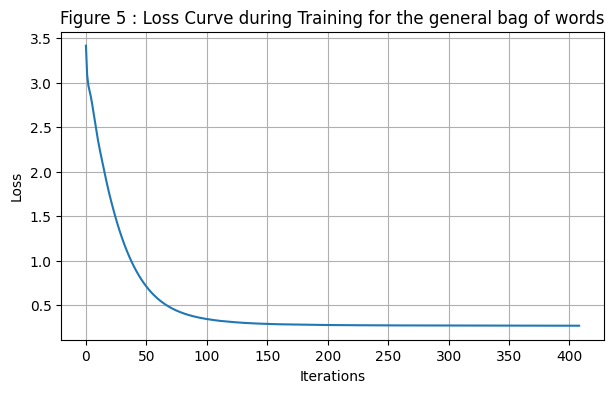

In [30]:
# Plot the loss curve
plt.figure(figsize = (7, 4))
plt.plot(clf_neurons2.loss_curve_)
plt.title('Figure 5 : Loss Curve during Training for the general bag of words')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [31]:
# Confusion matrix
cm2 = confusion_matrix(y_test2, y_pred2)
cm_df2 = pd.DataFrame(cm2, index=['Not Cheat', 'Cheat'], columns=['Predicted Not Cheat', 'Predicted Cheat'])
print("Confusion Matrix:")
print(cm_df2)

Confusion Matrix:
           Predicted Not Cheat  Predicted Cheat
Not Cheat                  390                7
Cheat                       53                1


In [32]:
# Recall calculation on test data
recall_test = recall_score(y_test2, y_pred2)
print("recall test =", recall_test)

# Prediction on training data
y_train_pred2 = reg2.predict(X_train2)

# Recall calculation based on training data
recall_train = recall_score(y_train2, y_train_pred2)
print("recall train =", recall_train) 

# Difference between training and test recall
print("recall train - recall test =",recall_train - recall_test)

recall test = 0.018518518518518517
recall train = 0.028037383177570093
recall train - recall test = 0.009518864659051576


Another bias issue arises, so we need to switch to a dataset with more features: the word embeddings.

### 8.2.3 Neural Network using the word embeddings

In [33]:
# Neural Network using word embeddings NUMBER 1
clf_neurons3 = MLPClassifier(hidden_layer_sizes=(200,200), activation = 'relu',
                              solver='adam', max_iter = 500, alpha=15, tol = 1e-8, batch_size= 1000,
                              random_state = 666, verbose = True
                              )

# Train the network
clf_neurons3.fit(X_train3, y_train3)

# Predict on the test set
y_pred3 = clf_neurons3.predict(X_test3)

Iteration 1, loss = 4.17028473
Iteration 2, loss = 3.95800654
Iteration 3, loss = 3.85478275


Iteration 4, loss = 3.71717942
Iteration 5, loss = 3.56556907
Iteration 6, loss = 3.41890995
Iteration 7, loss = 3.28921786
Iteration 8, loss = 3.17069377
Iteration 9, loss = 3.05113304
Iteration 10, loss = 2.92799633
Iteration 11, loss = 2.80702215
Iteration 12, loss = 2.69341419
Iteration 13, loss = 2.58672685
Iteration 14, loss = 2.48278925
Iteration 15, loss = 2.38101835
Iteration 16, loss = 2.28189792
Iteration 17, loss = 2.18733993
Iteration 18, loss = 2.09669640
Iteration 19, loss = 2.01044788
Iteration 20, loss = 1.92705089
Iteration 21, loss = 1.84662813
Iteration 22, loss = 1.76982538
Iteration 23, loss = 1.69630006
Iteration 24, loss = 1.62600485
Iteration 25, loss = 1.55876836
Iteration 26, loss = 1.49446913
Iteration 27, loss = 1.43245134
Iteration 28, loss = 1.37344483
Iteration 29, loss = 1.31729376
Iteration 30, loss = 1.26346081
Iteration 31, loss = 1.21213768
Iteration 32, loss = 1.16301469
Iteration 33, loss = 1.11589291
Iteration 34, loss = 1.07150018
Iteration 35, 

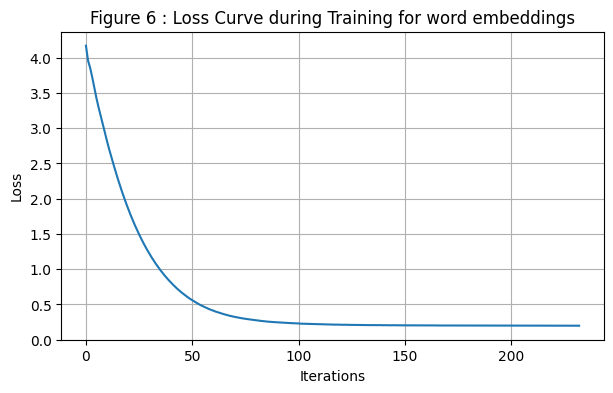

In [34]:
# Plot the loss curve
plt.figure(figsize = (7, 4))
plt.plot(clf_neurons3.loss_curve_)
plt.title('Figure 6 : Loss Curve during Training for word embeddings')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [35]:
# Confusion matrix
cm3 = confusion_matrix(y_test3, y_pred3)
cm_df3 = pd.DataFrame(cm3, index=['Not Cheat', 'Cheat'], columns=['Predicted Not Cheat', 'Predicted Cheat'])
print("Confusion Matrix:")
print(cm_df3)

Confusion Matrix:
           Predicted Not Cheat  Predicted Cheat
Not Cheat                  389                8
Cheat                       53                1


In [36]:
# Recall calculation on test data
recall_test = recall_score(y_test3, y_pred3)
print("recall test =", recall_test)

# Prediction on training data
y_train_pred3 = reg3.predict(X_train3)

# Recall calculation based on training data
recall_train = recall_score(y_train3, y_train_pred3)
print("recall train =", recall_train) 

# Difference between training and test recall
print("recall train - recall test =",recall_train - recall_test)

recall test = 0.018518518518518517
recall train = 0.17757009345794392
recall train - recall test = 0.1590515749394254


In the end, we face both a variance and a bias problem. We can't add more features, and since the neural network with word embeddings is our most powerful model, we need to optimize it for better efficiency. To address this, we can first focus on reducing bias by lowering the learning rate or increasing the network's complexity by adding more layers and hidden units.

## 8.3 Optimizing Our Best Model: Neural Network with Word Embeddings

In [37]:
# Neural Network with word embeddings NUMBER 2
clf_neurons4 = MLPClassifier(hidden_layer_sizes=(300,300, 200), activation = 'relu',
                              solver='adam', max_iter = 999, alpha= 5, tol = 1e-8, batch_size= 1000, learning_rate='constant', learning_rate_init=0.001,
                              random_state = 666, verbose = True
                              )

# Train the network
clf_neurons4.fit(X_train3, y_train3)

# Predict on the test set
y_pred3 = clf_neurons4.predict(X_test3)

Iteration 1, loss = 3.05690804
Iteration 2, loss = 2.69326701
Iteration 3, loss = 2.68965241
Iteration 4, loss = 2.60521934
Iteration 5, loss = 2.50540992
Iteration 6, loss = 2.43975809
Iteration 7, loss = 2.38951443
Iteration 8, loss = 2.33292828
Iteration 9, loss = 2.26503469
Iteration 10, loss = 2.19537119
Iteration 11, loss = 2.13298746
Iteration 12, loss = 2.07617478
Iteration 13, loss = 2.01917263
Iteration 14, loss = 1.95983329
Iteration 15, loss = 1.89928257
Iteration 16, loss = 1.84294631
Iteration 17, loss = 1.78917179
Iteration 18, loss = 1.73647522
Iteration 19, loss = 1.68311188
Iteration 20, loss = 1.63073676
Iteration 21, loss = 1.58109819
Iteration 22, loss = 1.53228342
Iteration 23, loss = 1.48350501
Iteration 24, loss = 1.43602150
Iteration 25, loss = 1.39018489
Iteration 26, loss = 1.34484080
Iteration 27, loss = 1.29982566
Iteration 28, loss = 1.25616532
Iteration 29, loss = 1.21322830
Iteration 30, loss = 1.17043437
Iteration 31, loss = 1.12826506
Iteration 32, los

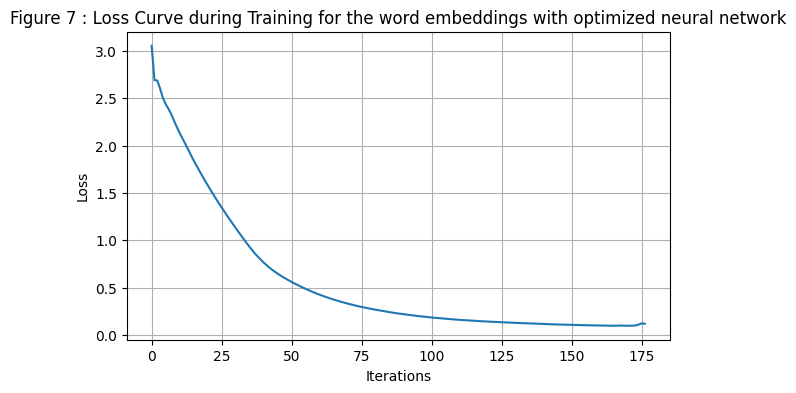

In [38]:
# Plot the loss curve
plt.figure(figsize = (7, 4))
plt.plot(clf_neurons4.loss_curve_)
plt.title('Figure 7 : Loss Curve during Training for the word embeddings with optimized neural network')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [39]:
# Confusion matrix
cm3 = confusion_matrix(y_test3, y_pred3)
cm_df3 = pd.DataFrame(cm3, index=['Not Cheat', 'Cheat'], columns=['Predicted Not Cheat', 'Predicted Cheat'])
print("Confusion Matrix:")
print(cm_df3)

Confusion Matrix:
           Predicted Not Cheat  Predicted Cheat
Not Cheat                  362               35
Cheat                       44               10


In [40]:
# Recall calculation on test data
recall_test = recall_score(y_test3, y_pred3)
print("recall test =", recall_test)

# Prediction on training data
y_train_pred3 = reg3.predict(X_train3)

# Recall calculation based on training data
recall_train = recall_score(y_train3, y_train_pred3)
print("recall train =", recall_train) 

# Difference between training and test recall
print("recall train - recall test =",recall_train - recall_test)

recall test = 0.18518518518518517
recall train = 0.17757009345794392
recall train - recall test = -0.007615091727241258


We have minimized the variance with this last model, but we are still facing a bias issue, even with a more sophisticated neural network.

## 8.4 New strategy

We will address the class imbalance by first testing logistic regression, which accounts for this imbalance.

### 8.4.1 New logistic regression using the word embeddings

In [41]:
# Initialize the model with automatic class balancing
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Train the model
log_reg.fit(X_train3, y_train3)

# Make predictions
y_pred = log_reg.predict(X_test3)

In [42]:
# Confusion matrix
cm3 = confusion_matrix(y_test3, y_pred)
cm_df3 = pd.DataFrame(cm3, index=['Not Cheat', 'Cheat'], columns=['Predicted Not Cheat', 'Predicted Cheat'])
print("Confusion Matrix:")
print(cm_df3)

Confusion Matrix:
           Predicted Not Cheat  Predicted Cheat
Not Cheat                  278              119
Cheat                       33               21


In [43]:
# Recall calculation on test data
recall_test = recall_score(y_test3, y_pred)
print("recall test =", recall_test)

# Prediction on training data
y_train_pred3 = log_reg.predict(X_train3)

# Recall calculation based on training data
recall_train = recall_score(y_train3, y_train_pred3)
print("recall train =", recall_train)

# Difference between training and test recall
print("recall train - recall test =", recall_train - recall_test)

recall test = 0.3888888888888889
recall train = 0.8878504672897196
recall train - recall test = 0.4989615784008307


In [44]:
# Recall calculation on test data
accuracy_test = accuracy_score(y_test3, y_pred)
print("accuracy test =", accuracy_test)

# Prediction on training data
y_train_pred3 = log_reg.predict(X_train3)

# Recall calculation based on training data
accuracy_train = accuracy_score(y_train3, y_train_pred3)
print("accuracy train =", accuracy_train)

# Difference between training and test recall
print("accuracy train - accuracy test =", accuracy_train - accuracy_test)

accuracy test = 0.6629711751662971
accuracy train = 0.7849223946784922
accuracy train - accuracy test = 0.12195121951219512


We no longer have a bias problem, but a variance one. We can address this with regularization.

### 8.4.2 New logistic regression with L1 using the word embeddings

In [45]:
# Performing Logistic Regression L1
reg = LogisticRegression(C = 0.05, solver = 'saga', penalty = 'l1', class_weight='balanced', max_iter = 10000)
reg.fit(X_train3, y_train3)

coef5 = pd.Series(reg.coef_.flatten(), index = X_train3.columns)

# Test the logistic regression
y_pred = reg.predict(X_test3)

In [46]:
# Confusion matrix
cm3 = confusion_matrix(y_test3, y_pred)
cm_df3 = pd.DataFrame(cm3, index=['Not Cheat', 'Cheat'], columns=['Predicted Not Cheat', 'Predicted Cheat'])
print("Confusion Matrix:")
print(cm_df3)

Confusion Matrix:
           Predicted Not Cheat  Predicted Cheat
Not Cheat                  240              157
Cheat                       27               27


In [47]:

# Recall calculation on test data
recall_test = recall_score(y_test3, y_pred)
print("recall test =", recall_test)

# Prediction on training data
y_train_pred = reg.predict(X_train3)

# Recall calculation based on training data
recall_train = recall_score(y_train3, y_train_pred)
print("recall train =", recall_train)

# Difference between training and test recall
print("recall train - recall test =", recall_train - recall_test)

# Accuracy calculation on test data
accuracy_test = accuracy_score(y_test3, y_pred)
print("accuracy test =", accuracy_test)

# Accuracy calculation based on training data
accuracy_train = accuracy_score(y_train3, y_train_pred)
print("accuracy train =", accuracy_train)

# Difference between training and test accuracy
print("accuracy train - accuracy test =", accuracy_train - accuracy_test)


recall test = 0.5
recall train = 0.6822429906542056
recall train - recall test = 0.18224299065420557
accuracy test = 0.5920177383592018
accuracy train = 0.6574279379157428
accuracy train - accuracy test = 0.06541019955654104


Here, we can see that while the variance problem has been minimized, the bias problem has increased slightly. If we had more resources and time, we could develop a neural network that also accounts for the class imbalance. Unfortunately, we need to conclude our analysis here.

# 9. Performance table

In [48]:
# Data for the table

data = [

    ["8.1.1", "df_specific_bag_of_words", "Logistic Regression", "0.023", "0.0", "Bias and Variance"],

    ["8.1.2", "df_general_bag_of_words", "Logistic Regression", "0.028", "0.018", " Bias and Variance"],

    ["8.1.3", "df_word_embedding", "Logistic Regression", "0.177", "0.055", " Bias and Variance"],

    ["8.2.1", "df_specific_bag_of_words", "Neural Network", "0.023", "0.0", "Bias and Variance"],

    ["8.2.2", "df_general_bag_of_words", "Neural Network", "0.028", "0.018", "Bias and Variance"],

    ["8.2.3", "df_word_embedding", "Neural Network", "0.177", "0.018", "Bias and Variance"],

    ["8.3", "df_word_embeddings", "Optimized Neural Network", "0.177", "0.185", "Bias"],

    ["8.4.1", "df_word_embedding", "Logistic regression", "0.887", "0.388", "Variance"],

    ["8.4.2", "df_sentence_embedding", "Logistic regression with L1", "0.682", "0.5", "Bias and Variance"],


]

 

# Create a DataFrame

columns = ["Test ID", "DataFrame", "Model", "Training Recall", "Test Recall", "Problem"]

df = pd.DataFrame(data, columns=columns)

 

# Set column display width to avoid overlap in Jupyter/Terminal

pd.set_option('display.max_colwidth', None)

 

# Display the DataFrame

display(df)

,Test ID,DataFrame,Model,Training Recall,Test Recall,Problem
0,8.1.1,df_specific_bag_of_words,Logistic Regression,0.023,0.0,Bias and Variance
1,8.1.2,df_general_bag_of_words,Logistic Regression,0.028,0.018,Bias and Variance
2,8.1.3,df_word_embedding,Logistic Regression,0.177,0.055,Bias and Variance
3,8.2.1,df_specific_bag_of_words,Neural Network,0.023,0.0,Bias and Variance
4,8.2.2,df_general_bag_of_words,Neural Network,0.028,0.018,Bias and Variance
5,8.2.3,df_word_embedding,Neural Network,0.177,0.018,Bias and Variance
6,8.3,df_word_embeddings,Optimized Neural Network,0.177,0.185,Bias
7,8.4.1,df_word_embedding,Logistic regression,0.887,0.388,Variance
8,8.4.2,df_sentence_embedding,Logistic regression with L1,0.682,0.5,Bias and Variance


# 10. Conclusion

Despite our efforts, predicting the presence of cheating in films has been challenging with the models we’ve built. The best-performing model so far is the L1 logistic regression, which gives us a reasonable recall score (train recall = 0.682, test recall = 0.5). However, logistic regression has limitations with highly nonlinear data and complex interactions. Moving to neural networks, which can also address class imbalance, seems like a logical next step, but it would require significant time and tuning.

The imbalance and complexity of the data limit model performance. Even with advanced techniques, improvements are difficult without altering the data. A promising approach would be to enrich the dataset, either by balancing the number of cheating and non-cheating films or by creating more relevant features, such as Textual question answering. Our current features don’t fully capture the connection between cheating and its portrayal, and improving them could boost model performance.